In [1]:
import sys
import os
sys.path.append('/app/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.error_report import get_error_from_list
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, ErrorEnum, FilterEnum, NoiseTypeEnum
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter


%matplotlib inline
np.random.seed(777)

# Load raw data 0033 (sequence number 09)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


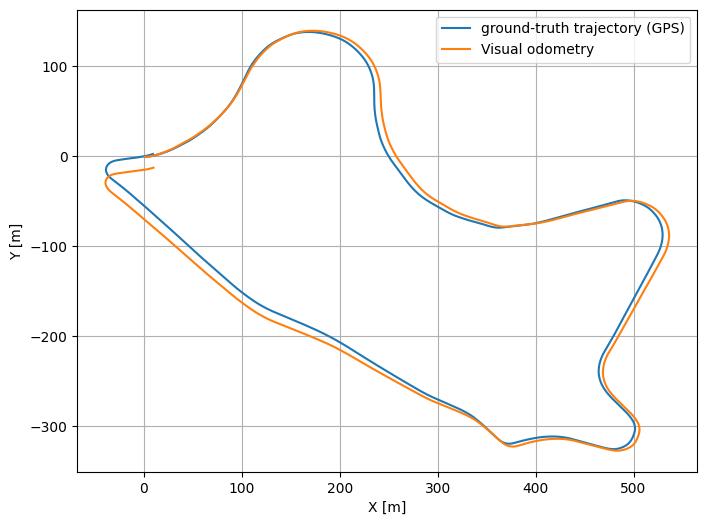

In [2]:
root_path = "../../../"
file_export_path = os.path.join(root_path, "exports/_sequences/09")
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0033'
noise_type = NoiseTypeEnum.CURRENT

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

## Display data with noise

### VO trajectory with noise

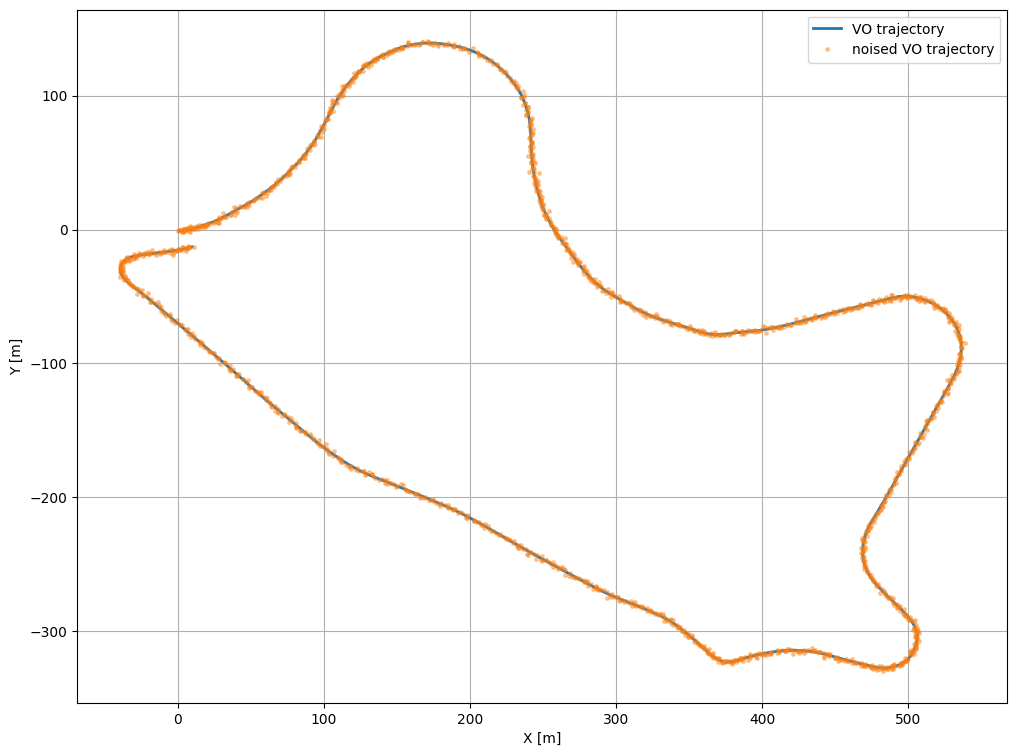

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

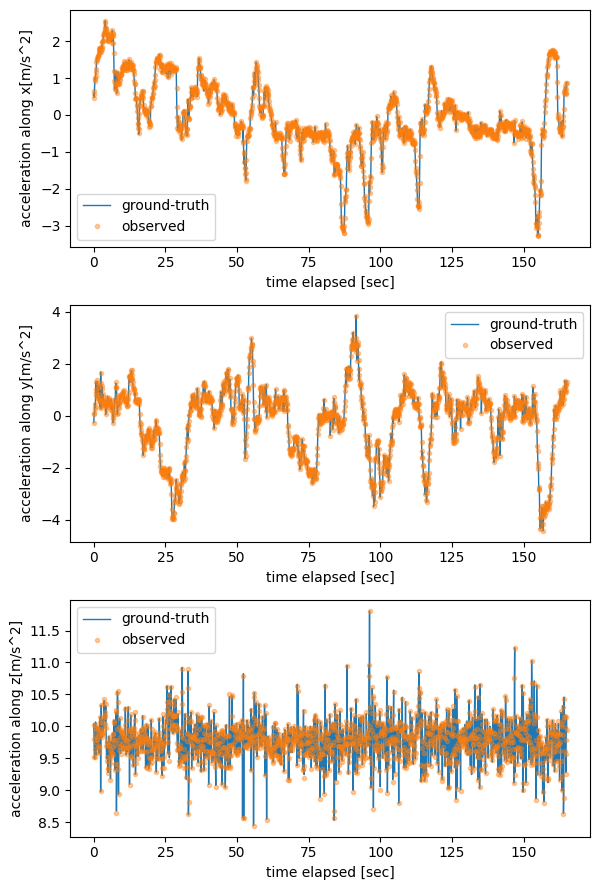

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

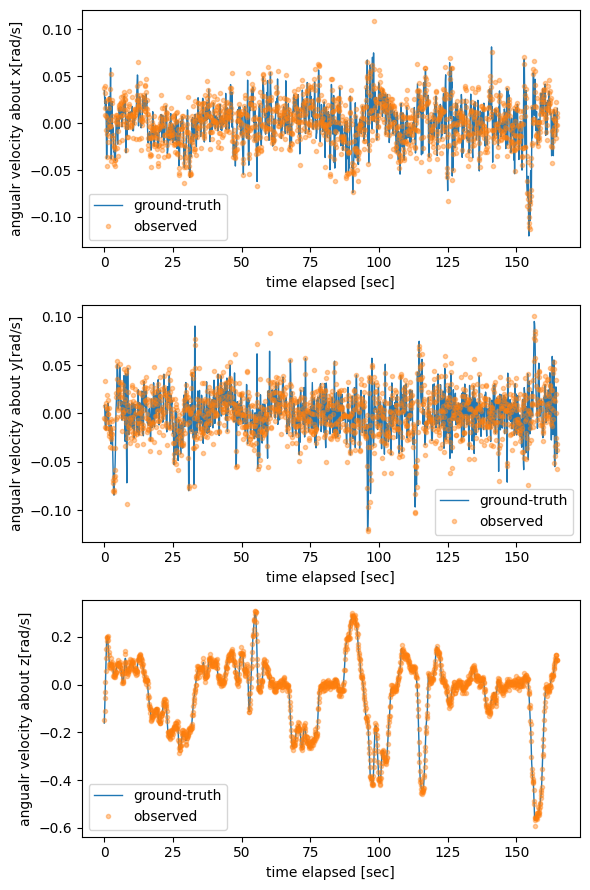

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

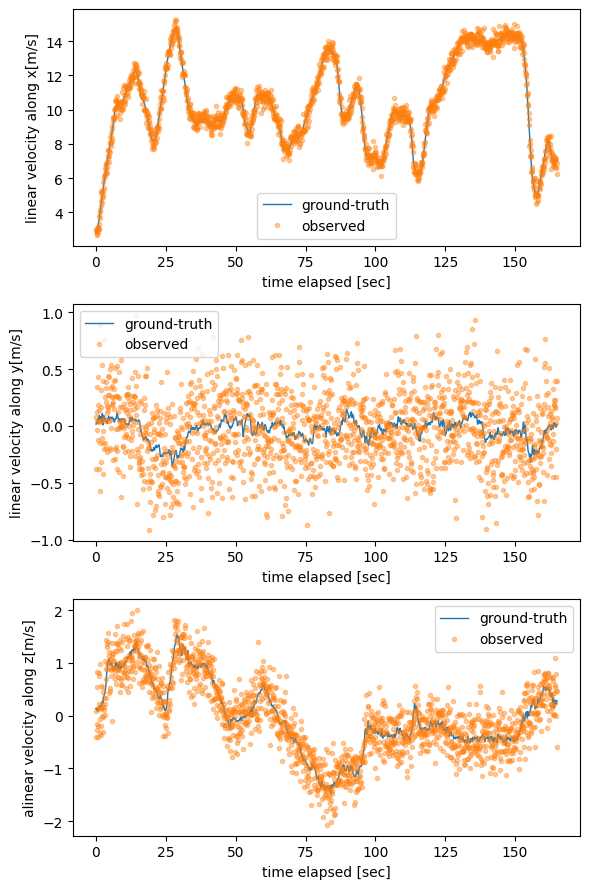

In [6]:
data.show_linear_velocity_with_noise()

# Applying filters

----

In [7]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS, VO+INS)'],
                                             ['EKF', 'UKF', 'PF', 'EnKF', 'CKF']],
                                            names=['Setups','Filter types'])
df_dropout_indices = ['No dropout', '10% drop', '20% drop', '30% drop', '40% drop']

def get_error_dataframe(error_0, error_10, error_20, error_30, error_40):
    mae_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAE)
    mae_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAE)
    mae_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAE)
    mae_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAE)
    mae_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAE)

    rmse_0 = get_error_from_list(error_0, e_type=ErrorEnum.RMSE)
    rmse_10 = get_error_from_list(error_10, e_type=ErrorEnum.RMSE)
    rmse_20 = get_error_from_list(error_20, e_type=ErrorEnum.RMSE)
    rmse_30 = get_error_from_list(error_30, e_type=ErrorEnum.RMSE)
    rmse_40 = get_error_from_list(error_40, e_type=ErrorEnum.RMSE)
    
    max_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAX)
    max_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAX)
    max_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAX)
    max_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAX)
    max_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAX)
    
    mae_error = [mae_0, mae_10, mae_20, mae_30, mae_40]
    rmse_error = [rmse_0, rmse_10, rmse_20, rmse_30, rmse_40]
    max_error = [max_0, max_10, max_20, max_30, max_40]
    
    mae_df = pd.DataFrame(np.array(mae_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    rmse_df = pd.DataFrame(np.array(rmse_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    max_df = pd.DataFrame(np.array(max_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    
    return mae_df, rmse_df, max_df



In [8]:
errors_0 = []
errors_10 = []
errors_20 = []
errors_30 = []
errors_40 = []

# No measurement data drop

In [9]:
data.change_dropout_ratio(vo_dropout_ratio=0.0, gps_dropout_ratio=0.0)

In [10]:
alpha_setup1_0 = 1.0
beta_setup1_0 = 2.0
kappa_setup1_0 = 0.0

alpha_setup2_0 = 1.0
beta_setup2_0 = 2.0
kappa_setup2_0 = 0.0

alpha_setup3_0 = 0.001
beta_setup3_0 = 2.0
kappa_setup3_0 = 0.0

n_samples_setup1_0 = 2048
resampling_algorithm_setup1_0 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_0 = 2048
resampling_algorithm_setup2_0 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup3_0 = 2048
resampling_algorithm_setup3_0 = ResamplingAlgorithms.STRATIFIED
importance_resampling = True

n_ensemble_setup1_0 = 2048
n_ensemble_setup2_0 = 2048
n_ensemble_setup3_0 = 2048

## Setup1

In [11]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_0 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_0 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_0, 
  beta=beta_setup1_0, 
  kappa=kappa_setup1_0,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_0 = ParticleFilter(
  N=n_samples_setup1_0, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_0
)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_0, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [12]:
error_ekf1_0 = ekf1_0.run(data=data, debug_mode=True)
error_ukf1_0 = ukf1_0.run(data=data, debug_mode=True)
error_pf1_0 = pf1_0.run(data=data, debug_mode=True, importance_resampling=importance_resampling)
error_enkf1_0 = enkf1_0.run(data=data, debug_mode=True)
error_ckf1_0 = ckf1_0.run(data=data, debug_mode=True)


errors_0.append(error_ekf1_0)
errors_0.append(error_ukf1_0)
errors_0.append(error_pf1_0)
errors_0.append(error_enkf1_0)
errors_0.append(error_ckf1_0)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 11312.90it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.904 m
Root Mean Squared Error: 5.486 m
Maximum Error: 16.056 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2506.99it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.17 m
Root Mean Squared Error: 5.682 m
Maximum Error: 16.566 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.92 m
Root Mean Squared Error: 5.498 m
Maximum Error: 16.775 m
--------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:38<00:00, 41.44it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.066 m
Root Mean Squared Error: 5.608 m
Maximum Error: 19.008 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2749.77it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.955 m
Root Mean Squared Error: 5.522 m
Maximum Error: 16.221 m
---------------------------------------------------



## Setup2

In [13]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_0 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_0 = ParticleFilter(
  N=n_samples_setup2_0, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_0
)
pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_0, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_0 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [14]:
error_ekf2_0 = ekf2_0.run(data=data, debug_mode=True)
error_ukf2_0 = ukf2_0.run(data=data, debug_mode=True)
error_pf2_0 = pf2_0.run(data=data, debug_mode=True, importance_resampling=importance_resampling)
error_enkf2_0 = enkf2_0.run(data=data, debug_mode=True)
error_ckf2_0 = ckf2_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf2_0)
errors_0.append(error_ukf2_0)
errors_0.append(error_pf2_0)
errors_0.append(error_enkf2_0)
errors_0.append(error_ckf2_0)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 10525.13it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.99 m
Root Mean Squared Error: 2.762 m
Maximum Error: 8.483 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 1902.74it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.509 m
Root Mean Squared Error: 2.01 m
Maximum Error: 6.659 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.554 m
Root Mean Squared Error: 0.701 m
Maximum Error: 3.504 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:51<00:00, 30.84it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.084 m
Root Mean Squared Error: 1.359 m
Maximum Error: 6.511 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2058.91it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.462 m
Root Mean Squared Error: 1.967 m
Maximum Error: 6.375 m
-------------------------------------------------------



## Setup3

In [15]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_0 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_0 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_0, 
  beta=beta_setup3_0, 
  kappa=kappa_setup3_0,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_0 = ParticleFilter(
  N=n_samples_setup3_0, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_0
)
pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_0, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_0 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [16]:
error_ekf3_0 = ekf3_0.run(data=data, debug_mode=True)
error_ukf3_0 = ukf3_0.run(data=data, debug_mode=True)
error_pf3_0 = pf3_0.run(data=data, debug_mode=True, importance_resampling=importance_resampling)
error_enkf3_0 = enkf3_0.run(data=data, debug_mode=True)
error_ckf3_0 = ckf3_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf3_0)
errors_0.append(error_ukf3_0)
errors_0.append(error_pf3_0)
errors_0.append(error_enkf3_0)
errors_0.append(error_ckf3_0)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 20096.68it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.948 m
Root Mean Squared Error: 2.737 m
Maximum Error: 8.202 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6719.43it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.549 m
Root Mean Squared Error: 2.098 m
Maximum Error: 6.744 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.425 m
Root Mean Squared Error: 0.553 m
Maximum Error: 2.254 m
----------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:25<00:00, 62.99it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.951 m
Root Mean Squared Error: 1.204 m
Maximum Error: 4.9 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6294.15it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.55 m
Root Mean Squared Error: 2.099 m
Maximum Error: 6.745 m
-----------------------------------------------



# 10% drop

In [17]:
data.change_dropout_ratio(vo_dropout_ratio=0.1, gps_dropout_ratio=0.1)

In [18]:
alpha_setup1_10 = 1.0
beta_setup1_10 = 2.0
kappa_setup1_10 = 0.0

alpha_setup2_10 = 1.0
beta_setup2_10 = 2.0
kappa_setup2_10 = 0.0

alpha_setup3_10 = 0.001
beta_setup3_10 = 2.0
kappa_setup3_10 = 0.0

n_samples_setup1_10 = 2048
resampling_algorithm_setup1_10 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_10 = 2048
resampling_algorithm_setup2_10 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup3_10 = 2048
resampling_algorithm_setup3_10 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_10 = 2048
n_ensemble_setup2_10 = 2048
n_ensemble_setup3_10 = 2048

## Setup1

In [19]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_10 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_10 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_10, 
  beta=beta_setup1_10, 
  kappa=kappa_setup1_10,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_10 = ParticleFilter(
  N=n_samples_setup1_10, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_10
)
pf1_10.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_10, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_10 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [20]:
error_ekf1_10 = ekf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_10 = ukf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_10 = pf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True,
)
error_enkf1_10 = enkf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_10 = ckf1_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_10.append(error_ekf1_10)
errors_10.append(error_ukf1_10)
errors_10.append(error_pf1_10)
errors_10.append(error_enkf1_10)
errors_10.append(error_ckf1_10)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 11386.92it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.904 m
Root Mean Squared Error: 5.493 m
Maximum Error: 16.076 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2341.16it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.279 m
Root Mean Squared Error: 5.662 m
Maximum Error: 16.74 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.918 m
Root Mean Squared Error: 5.511 m
Maximum Error: 16.862 m
--------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:36<00:00, 42.99it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.078 m
Root Mean Squared Error: 5.648 m
Maximum Error: 20.984 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2251.87it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.888 m
Root Mean Squared Error: 5.469 m
Maximum Error: 15.89 m
---------------------------------------------------



## Setup2

In [21]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_10 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_10 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_10, 
    beta=beta_setup2_10, 
    kappa=kappa_setup2_10,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_10 = ParticleFilter(
  N=n_samples_setup2_10, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_10
)
pf2_10.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_10, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_10 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [22]:
error_ekf2_10 = ekf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_10 = ukf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_10 = pf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_10 = enkf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_10 = ckf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_10.append(error_ekf2_10)
errors_10.append(error_ukf2_10)
errors_10.append(error_pf2_10)
errors_10.append(error_enkf2_10)
errors_10.append(error_ckf2_10)

[EKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 9390.96it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.994 m
Root Mean Squared Error: 2.828 m
Maximum Error: 12.02 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 1929.06it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.633 m
Root Mean Squared Error: 2.354 m
Maximum Error: 15.017 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.711 m
Root Mean Squared Error: 1.068 m
Maximum Error: 9.364 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:50<00:00, 31.31it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.429 m
Root Mean Squared Error: 2.442 m
Maximum Error: 18.105 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2087.43it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.567 m
Root Mean Squared Error: 2.286 m
Maximum Error: 14.846 m
-------------------------------------------------------



## Setup3

In [23]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_10 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_10 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_10, 
  beta=beta_setup3_10, 
  kappa=kappa_setup3_10,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_10 = ParticleFilter(
  N=n_samples_setup3_10, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_10
)
pf3_10.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_10, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_10 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [24]:
error_ekf3_10 = ekf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_10 = ukf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_10 = pf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_10 = enkf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_10 = ckf3_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_10.append(error_ekf3_10)
errors_10.append(error_ukf3_10)
errors_10.append(error_pf3_10)
errors_10.append(error_enkf3_10)
errors_10.append(error_ckf3_10)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 17507.88it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.959 m
Root Mean Squared Error: 2.781 m
Maximum Error: 9.799 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6140.42it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.608 m
Root Mean Squared Error: 2.293 m
Maximum Error: 12.358 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.547 m
Root Mean Squared Error: 0.87 m
Maximum Error: 9.556 m
----------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:22<00:00, 69.51it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.338 m
Root Mean Squared Error: 2.255 m
Maximum Error: 17.529 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6781.45it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.608 m
Root Mean Squared Error: 2.294 m
Maximum Error: 12.358 m
-----------------------------------------------



# 20% drop

In [25]:
data.change_dropout_ratio(vo_dropout_ratio=0.2, gps_dropout_ratio=0.2)

In [26]:
alpha_setup1_20 = 1.0
beta_setup1_20 = 2.0
kappa_setup1_20 = 0.0

alpha_setup2_20 = 1.0
beta_setup2_20 = 2.0
kappa_setup2_20 = 0.0

alpha_setup3_20 = 0.001
beta_setup3_20 = 2.0
kappa_setup3_20 = 0.0

n_samples_setup1_20 = 2048
resampling_algorithm_setup1_20 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_20 = 2048
resampling_algorithm_setup2_20 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup3_20 = 2048
resampling_algorithm_setup3_20 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_20 = 2048
n_ensemble_setup2_20 = 2048
n_ensemble_setup3_20 = 2048

## Setup1

In [27]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_20 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_20 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_20, 
  beta=beta_setup1_20, 
  kappa=kappa_setup1_20,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_20 = ParticleFilter(
  N=n_samples_setup1_20, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_20
)
pf1_20.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_20, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_20 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [28]:
error_ekf1_20 = ekf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_20 = ukf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_20 = pf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf1_20 = enkf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_20 = ckf1_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_20.append(error_ekf1_20)
errors_20.append(error_ukf1_20)
errors_20.append(error_pf1_20)
errors_20.append(error_enkf1_20)
errors_20.append(error_ckf1_20)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 11767.95it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.931 m
Root Mean Squared Error: 5.503 m
Maximum Error: 16.738 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2665.00it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.849 m
Root Mean Squared Error: 6.675 m
Maximum Error: 23.599 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.917 m
Root Mean Squared Error: 5.492 m
Maximum Error: 17.794 m
--------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:36<00:00, 44.10it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.1 m
Root Mean Squared Error: 5.641 m
Maximum Error: 19.358 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2615.29it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.939 m
Root Mean Squared Error: 5.564 m
Maximum Error: 17.073 m
---------------------------------------------------



## Setup2

In [29]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_20 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_20 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_20, 
    beta=beta_setup2_20, 
    kappa=kappa_setup2_20,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_20 = ParticleFilter(
  N=n_samples_setup2_20, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_20
)
pf2_20.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_20, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_20 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [30]:
error_ekf2_20 = ekf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_20 = ukf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_20 = pf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_20 = enkf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_20 = ckf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_20.append(error_ekf2_20)
errors_20.append(error_ukf2_20)
errors_20.append(error_pf2_20)
errors_20.append(error_enkf2_20)
errors_20.append(error_ckf2_20)

[EKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 8816.74it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2.006 m
Root Mean Squared Error: 2.877 m
Maximum Error: 16.115 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2078.87it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.719 m
Root Mean Squared Error: 2.583 m
Maximum Error: 17.479 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.83 m
Root Mean Squared Error: 1.305 m
Maximum Error: 13.813 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:47<00:00, 33.59it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.73 m
Root Mean Squared Error: 3.078 m
Maximum Error: 19.796 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2279.69it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.655 m
Root Mean Squared Error: 2.504 m
Maximum Error: 17.033 m
-------------------------------------------------------



## Setup3

In [31]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_20 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_20 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_20, 
  beta=beta_setup3_20, 
  kappa=kappa_setup3_20,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_20 = ParticleFilter(
  N=n_samples_setup3_20, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_20
)
pf3_20.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_20, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_20 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [32]:
error_ekf3_20 = ekf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_20 = ukf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_20 = pf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_20 = enkf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_20 = ckf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_20.append(error_ekf3_20)
errors_20.append(error_ukf3_20)
errors_20.append(error_pf3_20)
errors_20.append(error_enkf3_20)
errors_20.append(error_ckf3_20)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 10552.91it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.974 m
Root Mean Squared Error: 2.798 m
Maximum Error: 14.107 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 5208.80it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.676 m
Root Mean Squared Error: 2.445 m
Maximum Error: 15.697 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.669 m
Root Mean Squared Error: 1.16 m
Maximum Error: 10.356 m
----------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:19<00:00, 80.33it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.649 m
Root Mean Squared Error: 2.836 m
Maximum Error: 18.395 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 7168.34it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.677 m
Root Mean Squared Error: 2.445 m
Maximum Error: 15.698 m
-----------------------------------------------



# 30% drop

In [33]:
data.change_dropout_ratio(vo_dropout_ratio=0.3, gps_dropout_ratio=0.3)

In [34]:
alpha_setup1_30 = 0.0001
beta_setup1_30 = 2.0
kappa_setup1_30 = 0.0

alpha_setup2_30 = 1.0
beta_setup2_30 = 2.0
kappa_setup2_30 = 0.0

alpha_setup3_30 = 0.001
beta_setup3_30 = 2.0
kappa_setup3_30 = 0.0

n_samples_setup1_30 = 2048
resampling_algorithm_setup1_30 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_30 = 2048
resampling_algorithm_setup2_30 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup3_30 = 2048
resampling_algorithm_setup3_30 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_30 = 2048
n_ensemble_setup2_30 = 2048
n_ensemble_setup3_30 = 2048

## Setup1

In [35]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_30 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_30 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_30, 
  beta=beta_setup1_30, 
  kappa=kappa_setup1_30,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_30 = ParticleFilter(
  N=n_samples_setup1_30, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_30
)
pf1_30.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_30, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_30 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 12433.20it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.899 m
Root Mean Squared Error: 5.492 m
Maximum Error: 16.823 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2561.65it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 7.767 m
Root Mean Squared Error: 17.492 m
Maximum Error: 272.506 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.908 m
Root Mean Squared Error: 5.509 m
Maximum Error: 16.373 m
--------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:34<00:00, 45.61it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.075 m
Root Mean Squared Error: 5.636 m
Maximum Error: 17.382 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2868.23it/s]



----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.907 m
Root Mean Squared Error: 5.495 m
Maximum Error: 16.011 m
---------------------------------------------------



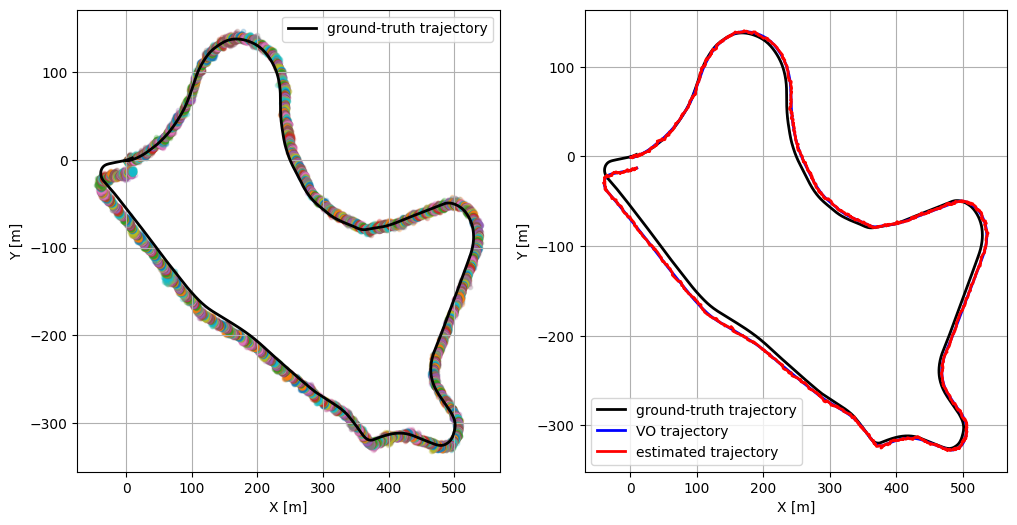

In [36]:
error_ekf1_30 = ekf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_30 = ukf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_30 = pf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True,
    show_graph=True
)
error_enkf1_30 = enkf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_30 = ckf1_30.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf1_30)
errors_30.append(error_ukf1_30)
errors_30.append(error_pf1_30)
errors_30.append(error_enkf1_30)
errors_30.append(error_ckf1_30)

## Setup2

In [37]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_30 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_30 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_30, 
    beta=beta_setup2_30, 
    kappa=kappa_setup2_30,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_30 = ParticleFilter(
  N=n_samples_setup2_30, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_30
)
pf2_30.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_30, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_30 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [38]:
error_ekf2_30 = ekf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_30 = ukf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_30 = pf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_30 = enkf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_30 = ckf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf2_30)
errors_30.append(error_ukf2_30)
errors_30.append(error_pf2_30)
errors_30.append(error_enkf2_30)
errors_30.append(error_ckf2_30)

[EKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 9616.29it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2.031 m
Root Mean Squared Error: 2.953 m
Maximum Error: 14.977 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2261.02it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.861 m
Root Mean Squared Error: 2.72 m
Maximum Error: 15.972 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.974 m
Root Mean Squared Error: 1.513 m
Maximum Error: 9.659 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:43<00:00, 36.49it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.967 m
Root Mean Squared Error: 3.357 m
Maximum Error: 20.44 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2339.30it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.737 m
Root Mean Squared Error: 2.629 m
Maximum Error: 15.925 m
-------------------------------------------------------



## Setup3

In [39]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_30 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_30 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_30, 
  beta=beta_setup3_30, 
  kappa=kappa_setup3_30,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_30 = ParticleFilter(
  N=n_samples_setup3_30, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_30
)
pf3_30.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_30, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_30 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [40]:
error_ekf3_30 = ekf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_30 = ukf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_30 = pf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_30 = enkf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_30 = ckf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)


errors_30.append(error_ekf3_30)
errors_30.append(error_ukf3_30)
errors_30.append(error_pf3_30)
errors_30.append(error_enkf3_30)
errors_30.append(error_ckf3_30)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 19422.26it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.992 m
Root Mean Squared Error: 2.836 m
Maximum Error: 13.551 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 7767.42it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.732 m
Root Mean Squared Error: 2.541 m
Maximum Error: 14.75 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.732 m
Root Mean Squared Error: 1.218 m
Maximum Error: 10.212 m
----------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:17<00:00, 88.94it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.848 m
Root Mean Squared Error: 3.069 m
Maximum Error: 17.859 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 7823.75it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.733 m
Root Mean Squared Error: 2.542 m
Maximum Error: 14.752 m
-----------------------------------------------



# 40% drop

In [41]:
data.change_dropout_ratio(vo_dropout_ratio=0.4, gps_dropout_ratio=0.4)

In [42]:
alpha_setup1_40 = 0.1000
beta_setup1_40 = 2.0
kappa_setup1_40 = 2.0

alpha_setup2_40 = 1.0
beta_setup2_40 = 2.0
kappa_setup2_40 = 0.0

alpha_setup3_40 = 0.001
beta_setup3_40 = 2.0
kappa_setup3_40 = 0.0

n_samples_setup1_40 = 2048
resampling_algorithm_setup1_40 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_40 = 2048
resampling_algorithm_setup2_40 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup3_40 = 2048
resampling_algorithm_setup3_40 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_40 = 2048
n_ensemble_setup2_40 = 2048
n_ensemble_setup3_40 = 2048

## Setup1

In [43]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_40 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_40 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_40, 
  beta=beta_setup1_40, 
  kappa=kappa_setup1_40,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_40 = ParticleFilter(
  N=n_samples_setup1_40, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_40
)
pf1_40.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_40, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_40 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [44]:
error_ekf1_40 = ekf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_40 = ukf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_40 = pf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf1_40 = enkf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_40 = ckf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_40.append(error_ekf1_40)
errors_40.append(error_ukf1_40)
errors_40.append(error_pf1_40)
errors_40.append(error_enkf1_40)
errors_40.append(error_ckf1_40)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 11721.76it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.895 m
Root Mean Squared Error: 5.481 m
Maximum Error: 15.984 m
---------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2833.93it/s]



----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 8.455 m
Root Mean Squared Error: 12.99 m
Maximum Error: 94.384 m
---------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.898 m
Root Mean Squared Error: 5.473 m
Maximum Error: 16.005 m
--------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:33<00:00, 47.68it/s]



----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.049 m
Root Mean Squared Error: 5.608 m
Maximum Error: 17.951 m
----------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2992.72it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 4.029 m
Root Mean Squared Error: 5.507 m
Maximum Error: 15.104 m
---------------------------------------------------



## Setup2

In [45]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_40 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_40 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_40, 
    beta=beta_setup2_40, 
    kappa=kappa_setup2_40,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_40 = ParticleFilter(
  N=n_samples_setup2_40, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_40
)
pf2_40.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_40, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_40 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [46]:
error_ekf2_40 = ekf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_40 = ukf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_40 = pf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf2_40 = enkf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_40 = ckf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf2_40)
errors_40.append(error_ukf2_40)
errors_40.append(error_pf2_40)
errors_40.append(error_enkf2_40)
errors_40.append(error_ckf2_40)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 10488.75it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2.03 m
Root Mean Squared Error: 3.062 m
Maximum Error: 16.923 m
-------------------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2388.26it/s]



----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.906 m
Root Mean Squared Error: 2.936 m
Maximum Error: 18.713 m
-------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.144 m
Root Mean Squared Error: 1.86 m
Maximum Error: 13.171 m
------------------------------------------------------

[EnKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:40<00:00, 39.07it/s]



----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2.219 m
Root Mean Squared Error: 3.863 m
Maximum Error: 25.364 m
--------------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2493.21it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.791 m
Root Mean Squared Error: 2.834 m
Maximum Error: 18.649 m
-------------------------------------------------------



## Setup3

In [47]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_40 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_40 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_40, 
  beta=beta_setup3_40, 
  kappa=kappa_setup3_40,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_40 = ParticleFilter(
  N=n_samples_setup3_40, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_40
)
pf3_40.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_40, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_40 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [48]:
error_ekf3_40 = ekf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_40 = ukf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_40 = pf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    importance_resampling=importance_resampling,
    debug_mode=True
)
error_enkf3_40 = enkf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_40 = ckf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf3_40)
errors_40.append(error_ukf3_40)
errors_40.append(error_pf3_40)
errors_40.append(error_enkf3_40)
errors_40.append(error_ckf3_40)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 20053.17it/s]



----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.971 m
Root Mean Squared Error: 2.849 m
Maximum Error: 14.523 m
-----------------------------------------------

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 8481.77it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.757 m
Root Mean Squared Error: 2.669 m
Maximum Error: 15.185 m
-----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.872 m
Root Mean Squared Error: 1.486 m
Maximum Error: 10.771 m
----------------------------------------------

[EnKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:14<00:00, 106.36it/s]



----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 2.122 m
Root Mean Squared Error: 3.51 m
Maximum Error: 17.269 m
------------------------------------------------

[CKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 8861.97it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.758 m
Root Mean Squared Error: 2.67 m
Maximum Error: 15.189 m
-----------------------------------------------



# Results

In [49]:
mae_df, rmse_df, max_df = get_error_dataframe(errors_0, errors_10, errors_20, errors_30, errors_40)

In [50]:
rmse_df

Setups       Setup1 (IMU, VO)                               \
Filter types              EKF     UKF     PF   EnKF    CKF   
No dropout              5.486   5.682  5.498  5.608  5.522   
10% drop                5.493   5.662  5.511  5.648  5.469   
20% drop                5.503   6.675  5.492  5.641  5.564   
30% drop                5.492  17.492  5.509  5.636  5.495   
40% drop                5.481  12.990  5.473  5.608  5.507   

Setups       Setup2(IMU, VO+GPS)                              \
Filter types                 EKF    UKF     PF   EnKF    CKF   
No dropout                 2.762  2.010  0.701  1.359  1.967   
10% drop                   2.828  2.354  1.068  2.442  2.286   
20% drop                   2.877  2.583  1.305  3.078  2.504   
30% drop                   2.953  2.720  1.513  3.357  2.629   
40% drop                   3.062  2.936  1.860  3.863  2.834   

Setups       Setup3(INS, VO+INS)                              
Filter types                 EKF    UKF     PF   EnKF    CKF  
No dropout                 2.737  2.098  0.553  1.204  2.099  
10% drop                   2.781  2.293  0.870  2.255  2.294  
20% drop                   2.798  2.445  1.160  2.836  2.445  
30% drop                   2.836  2.541  1.218  3.069  2.542  
40% drop                   2.849  2.669  1.486  3.510  2.670

In [51]:
max_df

Setups       Setup1 (IMU, VO)                                   \
Filter types              EKF      UKF      PF    EnKF     CKF   
No dropout             16.056   16.566  16.775  19.008  16.221   
10% drop               16.076   16.740  16.862  20.984  15.890   
20% drop               16.738   23.599  17.794  19.358  17.073   
30% drop               16.823  272.506  16.373  17.382  16.011   
40% drop               15.984   94.384  16.005  17.951  15.104   

Setups       Setup2(IMU, VO+GPS)                                  \
Filter types                 EKF     UKF      PF    EnKF     CKF   
No dropout                 8.483   6.659   3.504   6.511   6.375   
10% drop                  12.020  15.017   9.364  18.105  14.846   
20% drop                  16.115  17.479  13.813  19.796  17.033   
30% drop                  14.977  15.972   9.659  20.440  15.925   
40% drop                  16.923  18.713  13.171  25.364  18.649   

Setups       Setup3(INS, VO+INS)                                  
Filter types                 EKF     UKF      PF    EnKF     CKF  
No dropout                 8.202   6.744   2.254   4.900   6.745  
10% drop                   9.799  12.358   9.556  17.529  12.358  
20% drop                  14.107  15.697  10.356  18.395  15.698  
30% drop                  13.551  14.750  10.212  17.859  14.752  
40% drop                  14.523  15.185  10.771  17.269  15.189

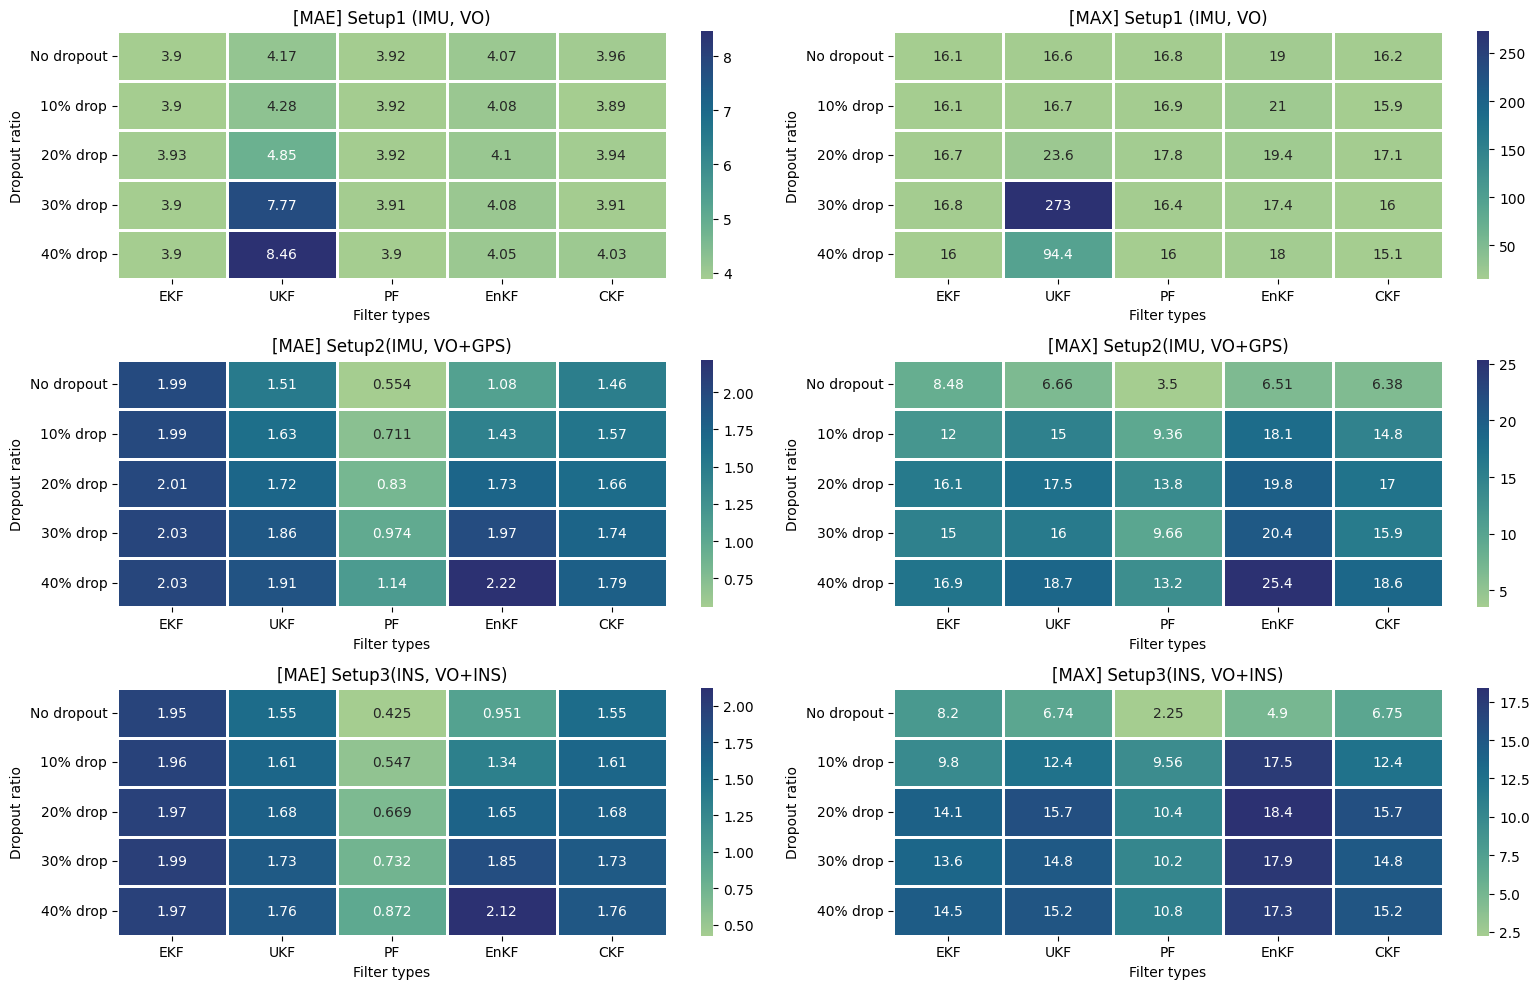

In [52]:
fig, (ax1_, ax2_, ax3_) = plt.subplots(nrows=3, ncols=2, figsize=(16, 10))
ax1, ax2 = ax1_[0], ax1_[1]
ax3, ax4 = ax2_[0], ax2_[1]
ax5, ax6 = ax3_[0], ax3_[1]

sns.heatmap(mae_df["Setup1 (IMU, VO)"],
            ax=ax1,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax1.set_title("[MAE] Setup1 (IMU, VO)")
ax1.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup2(IMU, VO+GPS)"],
            ax=ax3,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax3.set_title("[MAE] Setup2(IMU, VO+GPS)")
ax3.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup3(INS, VO+INS)"],
            ax=ax5,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax5.set_title("[MAE] Setup3(INS, VO+INS)")
ax5.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup1 (IMU, VO)"],
            ax=ax2,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax2.set_title("[MAX] Setup1 (IMU, VO)")
ax2.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup2(IMU, VO+GPS)"],
            ax=ax4,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax4.set_title("[MAX] Setup2(IMU, VO+GPS)")
ax4.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup3(INS, VO+INS)"],
            ax=ax6,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax6.set_title("[MAX] Setup3(INS, VO+INS)")
ax6.set(xlabel="Filter types", ylabel="Dropout ratio")

fig.tight_layout()

In [53]:
mae_df.to_json(os.path.join(file_export_path, "pf_guaranteed_mae_df.json"))
rmse_df.to_json(os.path.join(file_export_path, "pf_guaranteed_rmse_df.json"))
max_df.to_json(os.path.join(file_export_path, "pf_guaranteed_max_df.json"))

# Conclusion

In this notebook, sequence number 9 are utilized to demonstrate implemented Kalman Filters. Here, all implemented filtering algorithms are tested for each setup with increase of a dropout rate of measurement data. To avoid filter divergence, the particle size of Particle Filter is set to 2048.

In the setup 1, where IMU control input and VO measurement data are used, all the filters provide relatively the same quality of performance, but Extended Kalman Filter and Particle Filter have a slight better result than the other in terms of MAE and maximum error observed in the entire trajectory. Regarding UKF, its estimation deteriorates with increasing the dropout rate of measurement data.

In the setup 2, where IMU control input, VO and GPS measurement data are used, altough most of the filters experience the exponential maximum error growth as increase of the measurement data dropout, the particle filter retains less error grouth relative to the other filters interms of Maximum error in the trajectory. 

In the setup 3, where INS control input and VO and INS measurement data are used, the particle filter outperforms the other filters in terms of both MAE and maximum error in the entire trajectory.